# 05 · REINFORCE and policy gradients

[Course README](../README.md) · README topics **25–26**

**Goal.** Optimize action probabilities directly using complete episodes, implement a lagged baseline, and evaluate a learned stochastic policy.

**How to run:** select **Restart Kernel and Run All**. Every required function is defined
in this notebook; run cells in order. The defaults are small CPU experiments, not benchmark
training runs. Install the root `requirements.txt` once before opening Jupyter.
No cells install packages, download data, or require account credentials.

<img src="../assets/diagrams/actor-critic.svg" width="760" alt="Overview of REINFORCE and policy gradients">

## 1. Choose a route using a visible delivery cue

Each episode starts at position zero in a corridor. A cue says whether the parcel belongs
at the left or right exit, four moves away. Observations contain position, cue, and remaining
time. The policy chooses left or right. Correct delivery pays **+1**, the wrong exit pays
**−1**, ordinary moves pay **−0.01**, and a 12-action timeout pays **−0.2**. Terminal rewards
replace the ordinary move cost. Both exiting and exhausting this task budget truly terminate.

**Analogy:** after a delivery, make the route decisions associated with a better-than-expected
outcome more likely. A policy network outputs logits; a categorical distribution turns them
into action probabilities and supplies differentiable log probabilities.

This is REINFORCE, so we collect a complete episode before learning from its return. The
constant baseline below is not a learned state-value critic; notebook 6 introduces one.

In [1]:
import platform
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
INK, GOLD, SAGE, PLUM, PAPER = '#292332', '#AF824A', '#768165', '#87708C', '#F5F1E8'
plt.rcParams.update({
    'figure.figsize': (9, 4), 'figure.dpi': 110,
    'figure.facecolor': PAPER, 'axes.facecolor': PAPER,
    'text.color': INK, 'axes.labelcolor': INK, 'axes.edgecolor': INK,
    'xtick.color': INK, 'ytick.color': INK,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=[GOLD, SAGE, PLUM, INK]),
    'axes.grid': True, 'grid.alpha': 0.18,
})
np.set_printoptions(precision=3, suppress=True)
print(f'Python {platform.python_version()} | NumPy {np.__version__}')

import torch
from torch import nn
from torch.distributions import Categorical

# These tiny examples run on CPU; a single thread avoids thread-launch overhead.
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
DEVICE = torch.device('cpu')
print(f'PyTorch {torch.__version__} | device: {DEVICE}')

Python 3.12.4 | NumPy 1.26.4


PyTorch 2.11.0+cu130 | device: cpu


In [2]:
class CueCorridor:
    """Reach the exit named by a visible cue within a finite 12-action budget."""
    def __init__(self, seed, horizon=12, distance=4):
        self.rng = np.random.default_rng(seed)
        self.horizon, self.distance = horizon, distance

    def observation(self):
        return np.array([self.position/self.distance, self.cue,
                         self.remaining/self.horizon], dtype=np.float32)

    def reset(self):
        self.position, self.remaining = 0, self.horizon
        self.cue = int(self.rng.choice([-1, 1]))
        return self.observation()

    def step(self, action):
        self.position += -1 if action == 0 else 1
        self.remaining -= 1
        at_exit = abs(self.position) == self.distance
        success = at_exit and np.sign(self.position) == self.cue
        terminated = at_exit or self.remaining == 0
        reward = (1.0 if success else -1.0) if at_exit else (-0.2 if terminated else -0.01)
        return self.observation(), reward, terminated, {'success': success}

In [3]:
def policy_network():
    return nn.Sequential(nn.Linear(3, 32), nn.Tanh(), nn.Linear(32, 2)).to(DEVICE)

def discounted_returns(rewards, gamma):
    """Reward-to-go at every time, computed backward in O(episode length)."""
    result, total = [], 0.0
    for reward in reversed(rewards):
        total = float(reward) + gamma * total
        result.append(total)
    return torch.tensor(result[::-1], dtype=torch.float32)

assert torch.allclose(discounted_returns([-1, -1, 10], 0.9), torch.tensor([6.2, 8., 10.]))
print('Reward-to-go calculation matches the README example.')

Reward-to-go calculation matches the README example.


## 2. Collect complete episodes with a fixed policy

Keep network parameters unchanged while collecting each batch. We retain each sampled action's
log-probability graph and store rewards as plain numbers. The environment itself does not need
to be differentiable. A separate diagnostic is total undiscounted episode return.

In [4]:
def collect_episode(policy, env):
    """Sample one on-policy episode; preserve only the log-probability graph."""
    obs, log_probs, rewards = env.reset(), [], []
    while True:
        distribution = Categorical(logits=policy(torch.from_numpy(obs)))
        action = distribution.sample()
        log_probs.append(distribution.log_prob(action))
        obs, reward, terminated, _ = env.step(int(action))
        rewards.append(reward)
        if terminated: return torch.stack(log_probs), rewards

torch.manual_seed(7)
example_policy = policy_network()
log_probs, rewards = collect_episode(example_policy, CueCorridor(7))
print('Episode length:', len(rewards), '| return:', round(sum(rewards), 3))
print('Log-probability shape:', tuple(log_probs.shape))

Episode length: 8 | return: -1.07
Log-probability shape: (8,)


## 3. Implement the discounted start-state objective

```text
gradient estimate = sum_t gamma**t * grad(log pi(action_t | state_t)) * (G_t - baseline)
loss              = negative mean of those episode sums
```

The leading `gamma**t` matches the discounted start-state objective used in this course.
Returns are reward-to-go, so their own discounting starts again at each time step.

A baseline independent of the current action leaves the expected policy gradient unchanged.
We use an exponential moving average of **previous batches'** returns, updating it only after
the current actor update. Using the same sample's return as its own baseline would be wrong.
Baseline weights are detached from the actor gradient. A negative residual can discourage an
action even when its raw return was positive.

In [5]:
def train_reinforce(seed, use_baseline=True, updates=65, batch_episodes=16, gamma=0.98):
    """Monte Carlo policy optimization; return frozen policy and batch diagnostics."""
    torch.manual_seed(seed)
    policy = policy_network()
    env = CueCorridor(seed + 100)
    optimizer = torch.optim.Adam(policy.parameters(), lr=0.01)
    baseline = 0.0
    history, weight_variance = [], []
    for _ in range(updates):
        episodes = [collect_episode(policy, env) for _ in range(batch_episodes)]
        episode_losses, batch_weights = [], []
        for log_probs, rewards in episodes:
            returns = discounted_returns(rewards, gamma)
            weights = returns - (baseline if use_baseline else 0.0)
            discounts = gamma ** torch.arange(len(rewards), dtype=torch.float32)
            episode_losses.append(-(discounts * log_probs * weights.detach()).sum())
            batch_weights.extend(weights.tolist())
        loss = torch.stack(episode_losses).mean()
        optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(policy.parameters(), 5.0)
        optimizer.step()
        batch_return = np.mean([sum(rewards) for _, rewards in episodes])
        history.append(batch_return)
        weight_variance.append(np.var(batch_weights))
        # This value is used only by the next batch; it is independent of its actions.
        baseline = 0.9 * baseline + 0.1 * np.mean([discounted_returns(r, gamma)[0].item() for _, r in episodes])
    return policy.eval(), np.array(history), np.array(weight_variance)

SEEDS = [7, 19, 31]
experiments = {name: [train_reinforce(seed, use_baseline) for seed in SEEDS]
               for name, use_baseline in [('No baseline', False), ('Lagged baseline', True)]}
print('Trained both variants across', len(SEEDS), 'seeds.')

Trained both variants across 3 seeds.


## 4. Measure the policy we actually optimized

We evaluate **stochastic** action sampling, not just argmax behavior. Evaluation gets fresh
episode and action seeds and runs under `no_grad`. Success is the fraction of episodes
reaching the cued exit. All timeouts and wrong-exit episodes count as failures.

A scalar baseline need not reduce variance in every problem. The plot compares return;
the stored variance of sample weights is not the same as policy-gradient variance, which
also depends on the score-function gradients. Avoid claiming a variance reduction from
weight variance alone.

Untrained policy: return -0.584, success 7.3%


No baseline: success per seed [1. 1. 1.], mean return 0.966


Lagged baseline: success per seed [1. 1. 1.], mean return 0.969


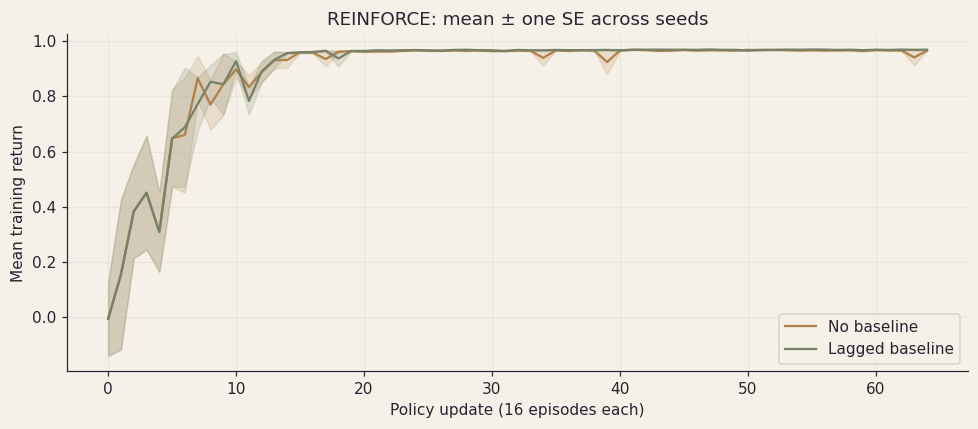

In [6]:
def evaluate_policy(policy, seed=2026, episodes=300):
    env = CueCorridor(seed)
    totals, successes = [], []
    # Restore the caller's PyTorch RNG state after evaluation.
    with torch.random.fork_rng(), torch.no_grad():
        torch.manual_seed(seed + 1)
        for _ in range(episodes):
            obs, total = env.reset(), 0.0
            while True:
                action = Categorical(logits=policy(torch.from_numpy(obs))).sample()
                obs, reward, done, info = env.step(int(action)); total += reward
                if done:
                    totals.append(total); successes.append(info['success']); break
    return np.mean(totals), np.mean(successes)

torch.manual_seed(123)
untrained_score = evaluate_policy(policy_network())
print(f'Untrained policy: return {untrained_score[0]:.3f}, success {untrained_score[1]:.1%}')
fig, ax = plt.subplots(figsize=(9, 4))
for name, runs in experiments.items():
    scores = np.array([evaluate_policy(policy) for policy, _, _ in runs])
    curves = np.stack([history for _, history, _ in runs])
    mean, se = curves.mean(0), curves.std(0, ddof=1) / np.sqrt(len(SEEDS))
    line, = ax.plot(mean, label=name)
    ax.fill_between(np.arange(len(mean)), mean-se, mean+se, color=line.get_color(), alpha=0.18)
    print(f'{name}: success per seed {np.round(scores[:, 1], 3)}, mean return {scores[:, 0].mean():.3f}')
    assert scores[:, 1].mean() > untrained_score[1]
ax.set(xlabel='Policy update (16 episodes each)', ylabel='Mean training return', title='REINFORCE: mean ± one SE across seeds')
ax.legend(); plt.tight_layout(); plt.show()

## 5. Verify the baseline identity directly

For a categorical policy, the expected gradient of `log pi(a)` is zero when weighted by
the same policy's probabilities. The following calculation sums over actions exactly,
with sampling weights detached. This is why subtracting an action-independent baseline
does not introduce an extra expected gradient term.

In [7]:
logits = torch.tensor([0.2, -0.4], requires_grad=True)
log_p = logits.log_softmax(dim=-1)
zero_expectation = (log_p.exp().detach() * log_p).sum()
gradient = torch.autograd.grad(zero_expectation, logits)[0]
assert torch.allclose(gradient, torch.zeros_like(gradient), atol=1e-7)
print('Expected score-function gradient:', gradient)

Expected score-function gradient: tensor([0., 0.])


## Exercises

1. Set gamma to 1 and explain which discount factors disappear.
2. Increase the corridor length. How does delayed credit assignment change?
3. Compare stochastic and greedy evaluation.
4. Replace the scalar baseline with a state-value network trained on returns.

<details>
<summary>Hints and expected reasoning — open after trying the exercises</summary>

1. Both reward-to-go discounting and the leading gamma**t weights become one.
2. Keep the horizon large enough to reach either exit; longer trajectories often increase variance.
3. Greedy behavior is a changed policy, so name the evaluation mode explicitly.
4. Detach the value prediction in the actor loss and use a separate regression loss for the critic.

</details>

## What to remember

Policy gradients change probabilities directly. Reward-to-go handles delayed credit, baselines provide relative feedback, and loss signs and gradient detachment matter.

## Further reading

- Williams, [Simple Statistical Gradient-Following Algorithms for Connectionist Reinforcement Learning](https://doi.org/10.1007/BF00992696).
- Sutton and Barto, [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html). Chapter 13.

[← Previous notebook](04_dqn.ipynb) · [Next notebook →](06_ppo.ipynb)